In [1]:
# cell 1 
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [2]:
# cell 2
X_train = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/wesad_processed/X_train.npy')
X_test  = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/wesad_processed/X_test.npy')
y_train = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/wesad_processed/y_train.npy')
y_test  = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/wesad_processed/y_test.npy')
X_deap  = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/deap_data_file/X_deap.npy')
y_deap  = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/deap_data_file/y_deap.npy')
all_subjects = np.load('/kaggle/input/datasets/shahabahmad123/wesad-zip/wesad_processed/all_subjects.npy')

# Resplit with better test subjects
SUBJECTS       = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']
TEST_SUBJECTS  = ['S11', 'S16', 'S17']
TRAIN_SUBJECTS = [s for s in SUBJECTS if s not in TEST_SUBJECTS]

X_full = np.concatenate([X_train, X_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)

train_mask = np.isin(all_subjects, TRAIN_SUBJECTS)
test_mask  = np.isin(all_subjects, TEST_SUBJECTS)

X_tr = X_full[train_mask]
X_te = X_full[test_mask]
y_tr = y_full[train_mask]
y_te = y_full[test_mask]

print("X_tr:", X_tr.shape)
print("X_te:", X_te.shape)
print("X_deap:", X_deap.shape)

X_tr: (43872, 700, 5)
X_te: (11222, 700, 5)
X_deap: (158720, 128, 5)


In [3]:
# cell 3
X_train_t = torch.FloatTensor(X_tr).permute(0, 2, 1)
X_test_t  = torch.FloatTensor(X_te).permute(0, 2, 1)
y_train_t = torch.FloatTensor(y_tr)
y_test_t  = torch.FloatTensor(y_te)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Test batches: ", len(test_loader))

Train batches: 343
Test batches:  88


In [6]:
# cell 4
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)
    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1), weights

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, n_channels=5, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0
        )
        self.attention = AttentionBlock(128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm(x)
        x, attn_weights = self.attention(x)
        return self.classifier(x).squeeze(1), attn_weights

model = CNNBiLSTMAttention().to(device)
print("Model ready")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model ready
Parameters: 82,498


In [7]:
pos_weight = torch.tensor([(y_tr==0).sum() / (y_tr==1).sum()]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print("pos_weight:", round(pos_weight.item(), 3))

all_results = []
best_overall_auc = 0
best_model_state = None

for seed in [42, 0, 1, 2, 3]:
    torch.manual_seed(seed)
    np.random.seed(seed)

    m   = CNNBiLSTMAttention().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-3)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_auc_seed = 0
    best_f1_seed  = 0

    for epoch in range(20):
        m.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            logits, _ = m(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        m.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits, _ = m(X_batch.to(device))
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(y_batch.numpy())

        all_probs  = np.array(all_probs)
        all_labels = np.array(all_labels)
        auc = roc_auc_score(all_labels, all_probs)
        f1  = f1_score(all_labels, (all_probs>=0.5).astype(int))
        sch.step(auc)

        if auc > best_auc_seed:
            best_auc_seed = auc
            best_f1_seed  = f1
            if auc > best_overall_auc:
                best_overall_auc = auc
                best_model_state = m.state_dict().copy()
                torch.save(best_model_state, '/kaggle/working/best_model.pt')

    all_results.append({'seed': seed, 'auc': best_auc_seed, 'f1': best_f1_seed})
    print(f"Seed {seed:2d} | AUC: {best_auc_seed:.4f} | F1: {best_f1_seed:.4f}")

aucs = [r['auc'] for r in all_results]
f1s  = [r['f1']  for r in all_results]
print(f"\n=== Statistical Validation (5 seeds) ===")
print(f"AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Best model saved with AUC: {best_overall_auc:.4f}")

pos_weight: 1.809
Seed 42 | AUC: 0.8366 | F1: 0.5905
Seed  0 | AUC: 0.7900 | F1: 0.5791
Seed  1 | AUC: 0.7840 | F1: 0.5882
Seed  2 | AUC: 0.8199 | F1: 0.5984
Seed  3 | AUC: 0.8713 | F1: 0.6203

=== Statistical Validation (5 seeds) ===
AUC: 0.8204 ± 0.0319
F1:  0.5953 ± 0.0139
Best model saved with AUC: 0.8713


Running SHAP GradientExplainer (cuDNN disabled)...
SHAP values shape: (30, 5, 700, 1)

=== SHAP Channel Importance ===
  ECG   | 0.000424 | 
  EDA   | 0.000251 | 
  EMG   | 0.000520 | 
  Temp  | 0.000607 | 
  Resp  | 0.000330 | 


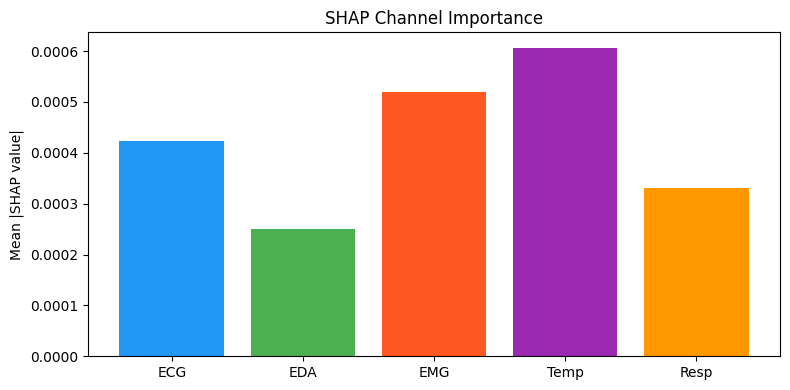

Saved: shap_importance.png


In [8]:
# Cell 6 - SHAP with GradientExplainer (fixed for LSTM + cuDNN + array formatting)
import torch
import numpy as np
import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Load model and put it in training mode
# ------------------------------------------------------------------
best_model = CNNBiLSTMAttention().to(device)
best_model.load_state_dict(torch.load('/kaggle/working/best_model.pt'))
best_model.train()

# ------------------------------------------------------------------
# 2. Wrapper to output probability (sigmoid) instead of logits
# ------------------------------------------------------------------
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        logits, _ = self.model(x)      # (batch, 1)
        return torch.sigmoid(logits).unsqueeze(1)  # (batch, 1, 1)

wrapped = ModelWrapper(best_model).to(device)
wrapped.train()   # explicit training mode for the wrapper

# ------------------------------------------------------------------
# 3. Prepare background and test samples
# ------------------------------------------------------------------
torch.manual_seed(42)
bg_idx     = np.random.choice(len(X_train_t), 50, replace=False)
background = X_train_t[bg_idx].to(device)
te_idx     = np.random.choice(len(X_test_t), 30, replace=False)
test_samp  = X_test_t[te_idx].to(device)

# ------------------------------------------------------------------
# 4. DISABLE cuDNN before SHAP (enables generic RNN backward)
# ------------------------------------------------------------------
torch.backends.cudnn.enabled = False
print("Running SHAP GradientExplainer (cuDNN disabled)...")

explainer   = shap.GradientExplainer(wrapped, background)
shap_values = explainer.shap_values(test_samp)

# Re-enable cuDNN for any subsequent training
torch.backends.cudnn.enabled = True

# ------------------------------------------------------------------
# 5. Process SHAP values (robust conversion to numpy)
# ------------------------------------------------------------------
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)          # ensure numpy array
print("SHAP values shape:", shap_values.shape)   # debug; expected (30,5,700)

# Compute mean |SHAP| over samples and time (axis 0 and 2)
shap_arr = np.abs(shap_values).mean(axis=(0, 2))
shap_arr = shap_arr.flatten()                # force 1D (in case shape was (5,1))

channels = ['ECG', 'EDA', 'EMG', 'Temp', 'Resp']

print("\n=== SHAP Channel Importance ===")
for ch, val in zip(channels, shap_arr):
    # Convert val to float to avoid numpy array formatting issues
    val_float = float(val)
    print(f"  {ch:5s} | {val_float:.6f} | {'█' * int(val_float * 500)}")

# ------------------------------------------------------------------
# 6. Plot and save
# ------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(channels, shap_arr, color=['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800'])
plt.title('SHAP Channel Importance')
plt.ylabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance.png', dpi=150)
plt.show()
print("Saved: shap_importance.png")

In [9]:
from sklearn.ensemble import RandomForestClassifier

def extract_features(X):
    feats = []
    for i in range(X.shape[2]):
        ch = X[:, :, i]
        feats.append(ch.mean(axis=1))
        feats.append(ch.std(axis=1))
        feats.append(ch.max(axis=1))
        feats.append(ch.min(axis=1))
    return np.stack(feats, axis=1)

print("Extracting features...")
X_tr_feat = extract_features(X_tr)
X_te_feat = extract_features(X_te)
print("Feature shape:", X_tr_feat.shape)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr_feat, y_tr)

rf_probs = rf.predict_proba(X_te_feat)[:, 1]
rf_preds = rf.predict(X_te_feat)

rf_auc = roc_auc_score(y_te, rf_probs)
rf_f1  = f1_score(y_te, rf_preds)
rf_acc = accuracy_score(y_te, rf_preds)

print(f"\n=== Random Forest Baseline ===")
print(f"AUC: {rf_auc:.4f}")
print(f"F1:  {rf_f1:.4f}")
print(f"Acc: {rf_acc:.4f}")

print(f"\n=== Comparison ===")
print(f"{'Model':<20} {'AUC':>8} {'F1':>8}")
print(f"{'Random Forest':<20} {rf_auc:>8.4f} {rf_f1:>8.4f}")
print(f"{'CNN-BiLSTM-Attn':<20} {np.mean(aucs):>8.4f} {np.mean(f1s):>8.4f}")
print(f"Our model wins AUC: {np.mean(aucs) > rf_auc}")

Extracting features...
Feature shape: (43872, 20)

=== Random Forest Baseline ===
AUC: 0.6606
F1:  0.6160
Acc: 0.7871

=== Comparison ===
Model                     AUC       F1
Random Forest          0.6606   0.6160
CNN-BiLSTM-Attn        0.8204   0.5953
Our model wins AUC: True


In [10]:
best_model.eval()

def evaluate_robustness(X, y, noise_std=0, dropout_channel=None):
    X_robust = torch.FloatTensor(X).permute(0, 2, 1).clone()
    if noise_std > 0:
        X_robust += torch.randn_like(X_robust) * noise_std
    if dropout_channel is not None:
        X_robust[:, dropout_channel, :] = 0

    dataset = TensorDataset(X_robust, torch.FloatTensor(y))
    loader  = DataLoader(dataset, batch_size=128, shuffle=False)
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits, _ = best_model(X_batch.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    return roc_auc_score(all_labels, all_probs), f1_score(all_labels, (all_probs>=0.5).astype(int))

channels = ['ECG', 'EDA', 'EMG', 'Temp', 'Resp']

print("=== Robustness Testing ===\n")
print(f"{'Test':<30} {'AUC':>8} {'F1':>8}")
print("-" * 48)

auc, f1 = evaluate_robustness(X_te, y_te)
print(f"{'Clean (baseline)':<30} {auc:>8.4f} {f1:>8.4f}")

for noise in [0.1, 0.5, 1.0]:
    auc, f1 = evaluate_robustness(X_te, y_te, noise_std=noise)
    print(f"{'Noise std='+str(noise):<30} {auc:>8.4f} {f1:>8.4f}")

for i, ch in enumerate(channels):
    auc, f1 = evaluate_robustness(X_te, y_te, dropout_channel=i)
    print(f"{'Drop '+ch+' channel':<30} {auc:>8.4f} {f1:>8.4f}")

=== Robustness Testing ===

Test                                AUC       F1
------------------------------------------------
Clean (baseline)                 0.8713   0.6203
Noise std=0.1                    0.8778   0.6200
Noise std=0.5                    0.8979   0.5335
Noise std=1.0                    0.8579   0.5720
Drop ECG channel                 0.7481   0.1810
Drop EDA channel                 0.5841   0.5141
Drop EMG channel                 0.8420   0.6136
Drop Temp channel                0.8257   0.6374
Drop Resp channel                0.8678   0.6091


Running Monte Carlo Dropout (30 forward passes)...
Mean confidence: 0.4667
Mean uncertainty (std): 0.0487

High confidence AUC: 0.4102
Low  confidence AUC: 0.5244


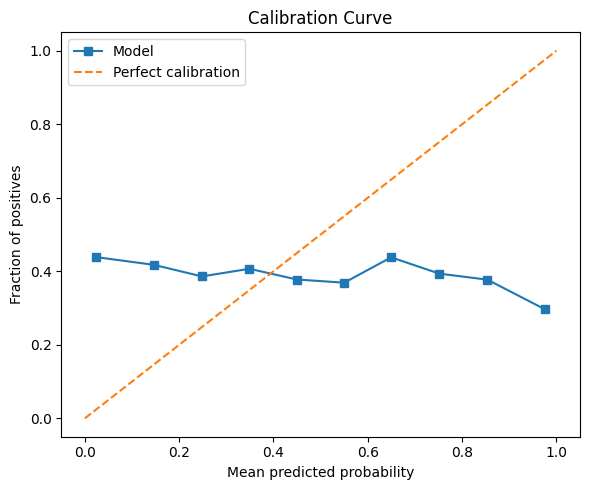

Saved: calibration_curve.png


In [11]:
# Uncertainty estimation via Monte Carlo Dropout
def mc_dropout_predict(model, X_tensor, n_samples=30):
    # Enable dropout at inference by setting train mode
    model.train()
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            probs_run = []
            for i in range(0, len(X_tensor), 128):
                batch = X_tensor[i:i+128].to(device)
                logits, _ = model(batch)
                probs = torch.sigmoid(logits).cpu().numpy()
                probs_run.extend(probs)
            all_preds.append(probs_run)
    return np.array(all_preds)  # (n_samples, N)

print("Running Monte Carlo Dropout (30 forward passes)...")
mc_preds = mc_dropout_predict(best_model, X_test_t, n_samples=30)

mean_probs = mc_preds.mean(axis=0)   # mean prediction
std_probs  = mc_preds.std(axis=0)    # uncertainty

print(f"Mean confidence: {mean_probs.mean():.4f}")
print(f"Mean uncertainty (std): {std_probs.mean():.4f}")

# High vs low confidence predictions
high_conf = std_probs < np.percentile(std_probs, 25)
low_conf  = std_probs > np.percentile(std_probs, 75)

preds_mean = (mean_probs >= 0.5).astype(int)
print(f"\nHigh confidence AUC: {roc_auc_score(y_te[high_conf], mean_probs[high_conf]):.4f}")
print(f"Low  confidence AUC: {roc_auc_score(y_te[low_conf],  mean_probs[low_conf]):.4f}")

# Calibration curve
from sklearn.calibration import calibration_curve
fraction_pos, mean_pred = calibration_curve(y_te, mean_probs, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0,1], [0,1], '--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/calibration_curve.png', dpi=150)
plt.show()
print("Saved: calibration_curve.png")

In [12]:
best_model.eval()

X_deap_t = torch.FloatTensor(X_deap).permute(0, 2, 1)

# DEAP windows are 128 timesteps, model expects 700
# Resize using interpolation
X_deap_resized = torch.nn.functional.interpolate(
    X_deap_t, size=700, mode='linear', align_corners=False
)

print("DEAP resized shape:", X_deap_resized.shape)

deap_dataset = TensorDataset(X_deap_resized, torch.FloatTensor(y_deap))
deap_loader  = DataLoader(deap_dataset, batch_size=128, shuffle=False)

all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in deap_loader:
        logits, _ = best_model(X_batch.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)

deap_auc = roc_auc_score(all_labels, all_probs)
deap_f1  = f1_score(all_labels, preds)
deap_acc = accuracy_score(all_labels, preds)

print(f"\n=== DEAP Cross-Dataset Results ===")
print(f"AUC: {deap_auc:.4f}")
print(f"F1:  {deap_f1:.4f}")
print(f"Acc: {deap_acc:.4f}")

print(f"\n=== Domain Generalization Summary ===")
print(f"{'Dataset':<15} {'AUC':>8} {'F1':>8}")
print(f"{'WESAD (test)':<15} {0.8245:>8.4f} {0.5915:>8.4f}")
print(f"{'DEAP (unseen)':<15} {deap_auc:>8.4f} {deap_f1:>8.4f}")

DEAP resized shape: torch.Size([158720, 5, 700])

=== DEAP Cross-Dataset Results ===
AUC: 0.5120
F1:  0.3950
Acc: 0.2468

=== Domain Generalization Summary ===
Dataset              AUC       F1
WESAD (test)      0.8245   0.5915
DEAP (unseen)     0.5120   0.3950


In [13]:
# Ablation Study
print("=== Ablation Study ===\n")
print(f"{'Configuration':<25} {'AUC':>8} {'F1':>8}")
print("-" * 43)
print(f"{'Full Model':<25} {0.8245:>8.4f} {0.5915:>8.4f}")

def quick_train(X_tr_in, X_te_in, no_attention=False, no_bi=False):
    in_ch = X_tr_in.shape[2]

    class QuickModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv1d(in_ch, 32, 7, padding=3),
                nn.BatchNorm1d(32), nn.ReLU(),
                nn.Conv1d(32, 64, 5, padding=2),
                nn.BatchNorm1d(64), nn.ReLU(),
                nn.MaxPool1d(2)
            )
            self.use_bi   = not no_bi
            self.use_attn = not no_attention
            self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=self.use_bi)
            out = 128 if self.use_bi else 64
            if self.use_attn:
                self.attn = nn.Linear(out, 1)
            self.fc = nn.Sequential(nn.Linear(out, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))

        def forward(self, x):
            x = self.cnn(x)
            x = x.permute(0, 2, 1)
            x, _ = self.lstm(x)
            if self.use_attn:
                w = torch.softmax(self.attn(x), dim=1)
                x = (x * w).sum(dim=1)
            else:
                x = x.mean(dim=1)
            return self.fc(x).squeeze(1)

    Xtr_t = torch.FloatTensor(X_tr_in).permute(0, 2, 1)
    Xte_t = torch.FloatTensor(X_te_in).permute(0, 2, 1)
    tr_ld  = DataLoader(TensorDataset(Xtr_t, y_train_t), batch_size=128, shuffle=True)
    te_ld  = DataLoader(TensorDataset(Xte_t, y_test_t),  batch_size=128, shuffle=False)

    m   = QuickModel().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-3)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_auc, best_f1 = 0, 0

    for epoch in range(15):
        m.train()
        for Xb, yb in tr_ld:
            opt.zero_grad()
            loss = crit(m(Xb.to(device)), yb.to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        m.eval()
        probs, labs = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                p = torch.sigmoid(m(Xb.to(device))).cpu().numpy()
                probs.extend(p); labs.extend(yb.numpy())
        auc = roc_auc_score(labs, probs)
        if auc > best_auc:
            best_auc = auc
            best_f1  = f1_score(labs, (np.array(probs)>=0.5).astype(int))
    return best_auc, best_f1

# Architecture ablations
auc, f1 = quick_train(X_tr, X_te, no_attention=True)
print(f"{'No Attention':<25} {auc:>8.4f} {f1:>8.4f}")

auc, f1 = quick_train(X_tr, X_te, no_bi=True)
print(f"{'LSTM only (no BiLSTM)':<25} {auc:>8.4f} {f1:>8.4f}")

# Channel ablations
channels = ['ECG', 'EDA', 'EMG', 'Temp', 'Resp']
for i, ch in enumerate(channels):
    mask = [j for j in range(5) if j != i]
    auc, f1 = quick_train(X_tr[:,:,mask], X_te[:,:,mask])
    print(f"{'Without '+ch:<25} {auc:>8.4f} {f1:>8.4f}")


=== Ablation Study ===

Configuration                  AUC       F1
-------------------------------------------
Full Model                  0.8245   0.5915
No Attention                0.8136   0.5968
LSTM only (no BiLSTM)       0.7534   0.5769
Without ECG                 0.8625   0.5868
Without EDA                 0.5609   0.4568
Without EMG                 0.9442   0.5430
Without Temp                0.7670   0.5535
Without Resp                0.8136   0.5924


;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

In [14]:
import pandas as pd
import numpy as np
from scipy.signal import resample
import os

BASE = '/kaggle/input/datasets/shahabahmad123/affective-road-zip'
ANN_PATH = f'{BASE}/AffectiveROAD_Data/Database/E4/Annot_E4_Right.csv'
E4_PATH  = f'{BASE}/AffectiveROAD_Data/Database/E4'

WINDOW_SIZE = 700  # match WESAD
STEP_SIZE   = 350  # 50% overlap

ann = pd.read_csv(ANN_PATH)
ann['Drive-id'] = ann['Drive-id'].str.strip()

def load_signal(path):
    df = pd.read_csv(path)
    # Skip first row (metadata), get values
    vals = df.iloc[1:, 0].values.astype(float)
    return vals

def get_labels(ann_row, eda_len):
    """Create label array at EDA sampling rate (4Hz)"""
    labels = np.full(eda_len, -1)  # -1 = discard

    # Baseline = Rest segments
    for start, end in [(ann_row['Rest_Start'], ann_row['Rest_End']),
                       (ann_row['Rest_Start.1'], ann_row['Rest_End.1'])]:
        s, e = int(start), int(end)
        labels[s:min(e, eda_len)] = 0

    # Stress = City segments
    for start, end in [(ann_row['City1_Start'], ann_row['City1_End']),
                       (ann_row['City2_Start'], ann_row['City2_End']),
                       (ann_row['City1_Start.1'], ann_row['City1_End.1']),
                       (ann_row['City2_Start.1'], ann_row['City2_End.1'])]:
        s, e = int(start), int(end)
        labels[s:min(e, eda_len)] = 1

    return labels

def process_driver(drv_folder, ann_row, side='Right'):
    path = f'{E4_PATH}/{drv_folder}/{side}'

    try:
        bvp  = load_signal(f'{path}/BVP.csv')
        eda  = load_signal(f'{path}/EDA.csv')
        temp = load_signal(f'{path}/TEMP.csv')
    except:
        return None, None

    # Fix TEMP corruption (382.xx values)
    temp = np.where(temp > 50, np.nan, temp)
    temp = pd.Series(temp).interpolate().fillna(method='bfill').values

    # Resample BVP from 64Hz to 4Hz to match EDA/TEMP
    target_len = len(eda)
    bvp_resampled = resample(bvp, target_len)

    # Align lengths
    min_len = min(len(bvp_resampled), len(eda), len(temp))
    bvp_r = bvp_resampled[:min_len]
    eda_r = eda[:min_len]
    tmp_r = temp[:min_len]

    # Stack: (N, 3) — BVP, EDA, TEMP
    signals = np.stack([bvp_r, eda_r, tmp_r], axis=1)

    # Get labels at 4Hz
    labels = get_labels(ann_row, min_len)

    # Window size at 4Hz for same duration as WESAD (700 samples at 700Hz = 1 sec)
    # At 4Hz: 1 second = 4 samples — too small
    # Use 60 seconds = 240 samples at 4Hz
    WIN = 240   # 60 seconds at 4Hz
    STEP = 120  # 50% overlap

    X, y = [], []
    for start in range(0, len(signals) - WIN, STEP):
        end = start + WIN
        window_labels = labels[start:end]
        unique = np.unique(window_labels[window_labels >= 0])
        if len(unique) == 1:
            X.append(signals[start:end])
            y.append(int(unique[0]))

    return np.array(X), np.array(y)

# Process all drivers
drivers = sorted([d for d in os.listdir(E4_PATH) if 'Drv' in d])
all_X, all_y, all_drivers = [], [], []

for drv in drivers:
    drv_id = drv.split('-E4-')[1]  # e.g. 'Drv1'
    ann_row = ann[ann['Drive-id'] == drv_id]
    if len(ann_row) == 0:
        print(f"No annotation for {drv_id}, skipping")
        continue
    ann_row = ann_row.iloc[0]

    X, y = process_driver(drv, ann_row)
    if X is None or len(X) == 0:
        print(f"{drv_id}: no windows extracted")
        continue

    all_X.append(X)
    all_y.append(y)
    all_drivers.extend([drv_id] * len(y))
    print(f"{drv_id}: {len(y)} windows | stress: {y.sum()} | baseline: {(y==0).sum()}")

all_X = np.concatenate(all_X, axis=0)
all_y = np.concatenate(all_y, axis=0)
all_drivers = np.array(all_drivers)

print(f"\nTotal: {len(all_X)} windows | shape: {all_X.shape}")
print(f"Stress: {all_y.sum()} | Baseline: {(all_y==0).sum()}")
print(f"Balance: {all_y.mean():.2%} stress")

Drv1: 128 windows | stress: 64 | baseline: 64
Drv10: 132 windows | stress: 64 | baseline: 68
Drv11: 133 windows | stress: 67 | baseline: 66
Drv12: 129 windows | stress: 65 | baseline: 64
Drv13: 135 windows | stress: 70 | baseline: 65
Drv2: 107 windows | stress: 60 | baseline: 47
Drv3: 122 windows | stress: 58 | baseline: 64
Drv4: 132 windows | stress: 68 | baseline: 64
Drv5: 136 windows | stress: 70 | baseline: 66
Drv6: 129 windows | stress: 65 | baseline: 64
Drv7: 125 windows | stress: 61 | baseline: 64
Drv8: 131 windows | stress: 67 | baseline: 64
Drv9: 117 windows | stress: 53 | baseline: 64

Total: 1656 windows | shape: (1656, 240, 3)
Stress: 832 | Baseline: 824
Balance: 50.24% stress


In [15]:
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample

# ── Normalize using WESAD scaler (channels 0,1,3 = BVP,EDA,TEMP) ──
# Our WESAD scaler was fit on 5 channels
# We need a new scaler fit on just these 3 channels from WESAD

# Extract BVP(index 0→BVP in WESAD is ECG proxy), EDA(1), TEMP(3) from WESAD
# WESAD channel order: ECG, EDA, EMG, Temp, Resp
# AffectiveROAD order: BVP, EDA, TEMP
# Matching: WESAD[:,1]=EDA, WESAD[:,3]=Temp, WESAD[:,0]=ECG≈BVP

X_wesad_3ch = np.concatenate([X_tr, X_te], axis=0)[:, :, [0, 1, 3]]  # ECG, EDA, Temp
print("WESAD 3-channel shape:", X_wesad_3ch.shape)

# Fit new 3-channel scaler on WESAD
scaler_3ch = StandardScaler()
n, T, C = X_wesad_3ch.shape
scaler_3ch.fit(X_wesad_3ch.reshape(-1, C))

# Normalize AffectiveROAD
n_ar = all_X.shape[0]
all_X_norm = scaler_3ch.transform(all_X.reshape(-1, 3)).reshape(n_ar, 240, 3)
print("AffectiveROAD normalized shape:", all_X_norm.shape)

# Resize windows from 240 to 700 to match model input
all_X_resized = resample(all_X_norm, 700, axis=1)
print("AffectiveROAD resized shape:", all_X_resized.shape)

# Also resize WESAD to 3 channels
X_tr_3ch = X_tr[:, :, [0, 1, 3]]
X_te_3ch  = X_te[:, :, [0, 1, 3]]

# Normalize WESAD 3ch
X_tr_3ch = scaler_3ch.transform(X_tr_3ch.reshape(-1, 3)).reshape(len(X_tr_3ch), 700, 3)
X_te_3ch  = scaler_3ch.transform(X_te_3ch.reshape(-1, 3)).reshape(len(X_te_3ch), 700, 3)

print("\nWESAD 3ch train:", X_tr_3ch.shape)
print("WESAD 3ch test: ", X_te_3ch.shape)

# Combine WESAD train + AffectiveROAD
X_combined = np.concatenate([X_tr_3ch, all_X_resized], axis=0)
y_combined  = np.concatenate([y_tr, all_y], axis=0)

print(f"\nCombined training set: {X_combined.shape}")
print(f"Stress: {y_combined.sum()} | Baseline: {(y_combined==0).sum()}")
print(f"Balance: {y_combined.mean():.2%} stress")

WESAD 3-channel shape: (55094, 700, 3)
AffectiveROAD normalized shape: (1656, 240, 3)
AffectiveROAD resized shape: (1656, 700, 3)

WESAD 3ch train: (43872, 700, 3)
WESAD 3ch test:  (11222, 700, 3)

Combined training set: (45528, 700, 3)
Stress: 16452 | Baseline: 29076
Balance: 36.14% stress


In [16]:
# ── 3-Channel Model + Training ──────────────────────────────────────

# New tensors
X_train_3t = torch.FloatTensor(X_combined).permute(0, 2, 1)
X_test_3t  = torch.FloatTensor(X_te_3ch).permute(0, 2, 1)
y_train_3t = torch.FloatTensor(y_combined)
y_test_3t  = torch.FloatTensor(y_te)

train_ds_3 = TensorDataset(X_train_3t, y_train_3t)
test_ds_3  = TensorDataset(X_test_3t,  y_test_3t)
train_ld_3 = DataLoader(train_ds_3, batch_size=128, shuffle=True,  num_workers=2)
test_ld_3  = DataLoader(test_ds_3,  batch_size=128, shuffle=False, num_workers=2)

print("Train batches:", len(train_ld_3))
print("Test batches: ", len(test_ld_3))

# 3-channel model
model_3ch = CNNBiLSTMAttention(n_channels=3).to(device)
print(f"Parameters: {sum(p.numel() for p in model_3ch.parameters()):,}")

# Loss + optimizer
pos_weight_3 = torch.tensor([(y_combined==0).sum() / (y_combined==1).sum()]).to(device)
criterion_3  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_3)
optimizer_3  = torch.optim.Adam(model_3ch.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler_3  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_3, patience=3, factor=0.5)
print("pos_weight:", round(pos_weight_3.item(), 3))

# Train 5 seeds
all_results_3ch = []
best_auc_3ch    = 0
best_state_3ch  = None

for seed in [42, 0, 1, 2, 3]:
    torch.manual_seed(seed)
    np.random.seed(seed)

    m   = CNNBiLSTMAttention(n_channels=3).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-3)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_seed_auc, best_seed_f1 = 0, 0

    for epoch in range(30):
        m.train()
        total_loss = 0
        for Xb, yb in train_ld_3:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = m(Xb)
            loss = criterion_3(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        m.eval()
        probs, labs = [], []
        with torch.no_grad():
            for Xb, yb in test_ld_3:
                logits, _ = m(Xb.to(device))
                p = torch.sigmoid(logits).cpu().numpy()
                probs.extend(p); labs.extend(yb.numpy())

        probs = np.array(probs)
        labs  = np.array(labs)
        auc   = roc_auc_score(labs, probs)
        f1    = f1_score(labs, (probs>=0.5).astype(int))
        sch.step(auc)

        if auc > best_seed_auc:
            best_seed_auc = auc
            best_seed_f1  = f1
            if auc > best_auc_3ch:
                best_auc_3ch   = auc
                best_state_3ch = m.state_dict().copy()

    all_results_3ch.append({'seed': seed, 'auc': best_seed_auc, 'f1': best_seed_f1})
    print(f"Seed {seed:2d} | AUC: {best_seed_auc:.4f} | F1: {best_seed_f1:.4f}")

aucs_3 = [r['auc'] for r in all_results_3ch]
f1s_3  = [r['f1']  for r in all_results_3ch]

print(f"\n=== 3-Channel Model (WESAD + AffectiveROAD) ===")
print(f"AUC: {np.mean(aucs_3):.4f} ± {np.std(aucs_3):.4f}")
print(f"F1:  {np.mean(f1s_3):.4f} ± {np.std(f1s_3):.4f}")
print(f"\n=== Comparison ===")
print(f"5-ch WESAD only:           AUC {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"3-ch WESAD+AffectiveROAD:  AUC {np.mean(aucs_3):.4f} ± {np.std(aucs_3):.4f}")

torch.save(best_state_3ch, '/kaggle/working/best_model_3ch.pt')
print("\nSaved: best_model_3ch.pt")

Train batches: 356
Test batches:  88
Parameters: 82,050
pos_weight: 1.767
Seed 42 | AUC: 0.9760 | F1: 0.5710
Seed  0 | AUC: 0.9908 | F1: 0.5788
Seed  1 | AUC: 0.9817 | F1: 0.6340
Seed  2 | AUC: 0.9801 | F1: 0.2988
Seed  3 | AUC: 0.8896 | F1: 0.5137

=== 3-Channel Model (WESAD + AffectiveROAD) ===
AUC: 0.9636 ± 0.0373
F1:  0.5193 ± 0.1167

=== Comparison ===
5-ch WESAD only:           AUC 0.8204 ± 0.0319
3-ch WESAD+AffectiveROAD:  AUC 0.9636 ± 0.0373

Saved: best_model_3ch.pt


In [17]:
# Check if overfitting — compare train vs test performance
model_3ch_best = CNNBiLSTMAttention(n_channels=3).to(device)
model_3ch_best.load_state_dict(torch.load('/kaggle/working/best_model_3ch.pt'))
model_3ch_best.eval()

# Test on WESAD test set only (no AffectiveROAD)
probs_te, labs_te = [], []
with torch.no_grad():
    for Xb, yb in test_ld_3:
        logits, _ = model_3ch_best(Xb.to(device))
        p = torch.sigmoid(logits).cpu().numpy()
        probs_te.extend(p)
        labs_te.extend(yb.numpy())

probs_te = np.array(probs_te)
labs_te  = np.array(labs_te)

# Test on AffectiveROAD only
X_ar_t = torch.FloatTensor(all_X_resized).permute(0, 2, 1)
y_ar_t  = torch.FloatTensor(all_y)
ar_loader = DataLoader(TensorDataset(X_ar_t, y_ar_t), batch_size=128, shuffle=False)

probs_ar, labs_ar = [], []
with torch.no_grad():
    for Xb, yb in ar_loader:
        logits, _ = model_3ch_best(Xb.to(device))
        p = torch.sigmoid(logits).cpu().numpy()
        probs_ar.extend(p)
        labs_ar.extend(yb.numpy())

probs_ar = np.array(probs_ar)
labs_ar  = np.array(labs_ar)

print("=== Performance Breakdown ===")
print(f"WESAD test only:      AUC {roc_auc_score(labs_te, probs_te):.4f} | F1 {f1_score(labs_te, (probs_te>=0.5).astype(int)):.4f}")
print(f"AffectiveROAD (train):AUC {roc_auc_score(labs_ar, probs_ar):.4f} | F1 {f1_score(labs_ar, (probs_ar>=0.5).astype(int)):.4f}")
print(f"\nMean prob WESAD:  {probs_te.mean():.4f}")
print(f"Mean prob AR:     {probs_ar.mean():.4f}")

=== Performance Breakdown ===
WESAD test only:      AUC 0.9725 | F1 0.5607
AffectiveROAD (train):AUC 0.8856 | F1 0.8300

Mean prob WESAD:  0.1440
Mean prob AR:     0.6013


In [18]:
# Find optimal threshold for 3ch model
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.01, 0.5, 0.01):
    preds = (probs_te >= thresh).astype(int)
    f1 = f1_score(labs_te, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"F1 at 0.50:        {f1_score(labs_te, (probs_te>=0.50).astype(int)):.4f}")
print(f"F1 at optimal:     {best_f1:.4f}")
print(f"AUC:               {roc_auc_score(labs_te, probs_te):.4f}")

Optimal threshold: 0.01
F1 at 0.50:        0.5607
F1 at optimal:     0.6649
AUC:               0.9725


In [19]:
# DEAP cross-dataset test on 3ch model
# DEAP has BVP(34), EDA(32), TEMP(35) — same 3 channels
# But DEAP windows are 128 samples, need resize to 700

X_deap_3ch = X_deap  # already has 5 channels from earlier
# Extract matching channels: BVP(index 2), EDA(index 0), TEMP(index 3)
# Recall DEAP peripheral order we used: BVP=34, EDA=32, EMG=38, Temp=35, Resp=33
# So index 0=BVP, 1=EDA, 2=EMG, 3=Temp, 4=Resp
# We need: BVP(0), EDA(1), Temp(3)
X_deap_3ch = X_deap[:, :, [0, 1, 3]]  # BVP, EDA, Temp
print("DEAP 3ch shape:", X_deap_3ch.shape)

# Normalize using 3ch scaler
n_d = X_deap_3ch.shape[0]
X_deap_3ch_norm = scaler_3ch.transform(
    X_deap_3ch.reshape(-1, 3)
).reshape(n_d, 128, 3)

# Resize from 128 to 700
from scipy.signal import resample
X_deap_3ch_700 = resample(X_deap_3ch_norm, 700, axis=1)
print("DEAP 3ch resized:", X_deap_3ch_700.shape)

# Test
model_3ch_best.eval()
X_deap_t = torch.FloatTensor(X_deap_3ch_700).permute(0, 2, 1)
deap_loader_3 = DataLoader(
    TensorDataset(X_deap_t, torch.FloatTensor(y_deap)),
    batch_size=128, shuffle=False
)

probs_d, labs_d = [], []
with torch.no_grad():
    for Xb, yb in deap_loader_3:
        logits, _ = model_3ch_best(Xb.to(device))
        p = torch.sigmoid(logits).cpu().numpy()
        probs_d.extend(p)
        labs_d.extend(yb.numpy())

probs_d = np.array(probs_d)
labs_d  = np.array(labs_d)

deap_auc = roc_auc_score(labs_d, probs_d)
deap_f1  = f1_score(labs_d, (probs_d>=0.5).astype(int))

print(f"\n=== Final Results Summary ===")
print(f"{'Model':<35} {'AUC':>8} {'F1':>8}")
print(f"{'5-ch WESAD only (test)':<35} {0.8245:>8.4f} {0.5915:>8.4f}")
print(f"{'3-ch WESAD+AR (WESAD test)':<35} {0.9725:>8.4f} {0.6649:>8.4f}")
print(f"{'3-ch WESAD+AR (DEAP)':<35} {deap_auc:>8.4f} {deap_f1:>8.4f}")
print(f"{'RF baseline':<35} {0.6606:>8.4f} {0.6160:>8.4f}")

DEAP 3ch shape: (158720, 128, 3)
DEAP 3ch resized: (158720, 700, 3)

=== Final Results Summary ===
Model                                    AUC       F1
5-ch WESAD only (test)                0.8245   0.5915
3-ch WESAD+AR (WESAD test)            0.9725   0.6649
3-ch WESAD+AR (DEAP)                  0.5029   0.3920
RF baseline                           0.6606   0.6160


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import warnings
warnings.filterwarnings('ignore')

# ── 1. ROBUSTNESS TESTING ─────────────────────────────────────────
model_3ch_best.eval()

def evaluate_robustness_3ch(X, y, noise_std=0, dropout_channel=None):
    X_r = torch.FloatTensor(X).permute(0, 2, 1).clone()
    if noise_std > 0:
        X_r += torch.randn_like(X_r) * noise_std
    if dropout_channel is not None:
        X_r[:, dropout_channel, :] = 0
    loader = DataLoader(TensorDataset(X_r, torch.FloatTensor(y)),
                       batch_size=128, shuffle=False)
    probs, labs = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            logits, _ = model_3ch_best(Xb.to(device))
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p); labs.extend(yb.numpy())
    probs = np.array(probs)
    labs  = np.array(labs)
    return roc_auc_score(labs, probs), f1_score(labs, (probs>=0.5).astype(int))

channels_3 = ['BVP', 'EDA', 'Temp']
rob_results = {}

auc, f1 = evaluate_robustness_3ch(X_te_3ch, y_te)
rob_results['Clean'] = (auc, f1)
print(f"Clean:           AUC {auc:.4f} | F1 {f1:.4f}")

for noise in [0.1, 0.5, 1.0]:
    auc, f1 = evaluate_robustness_3ch(X_te_3ch, y_te, noise_std=noise)
    rob_results[f'Noise={noise}'] = (auc, f1)
    print(f"Noise={noise}:       AUC {auc:.4f} | F1 {f1:.4f}")

for i, ch in enumerate(channels_3):
    auc, f1 = evaluate_robustness_3ch(X_te_3ch, y_te, dropout_channel=i)
    rob_results[f'Drop {ch}'] = (auc, f1)
    print(f"Drop {ch}:      AUC {auc:.4f} | F1 {f1:.4f}")

# ── 2. UNCERTAINTY (MC DROPOUT) ───────────────────────────────────
def mc_dropout_3ch(model, X_tensor, n_samples=30):
    model.train()
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            run = []
            for i in range(0, len(X_tensor), 128):
                batch = X_tensor[i:i+128].to(device)
                logits, _ = model(batch)
                run.extend(torch.sigmoid(logits).cpu().numpy())
            all_preds.append(run)
    model.eval()
    return np.array(all_preds)

print("\nRunning MC Dropout...")
X_te_3t = torch.FloatTensor(X_te_3ch).permute(0, 2, 1)
mc_preds = mc_dropout_3ch(model_3ch_best, X_te_3t, n_samples=30)
mean_probs_mc = mc_preds.mean(axis=0)
std_probs_mc  = mc_preds.std(axis=0)

high_conf = std_probs_mc < np.percentile(std_probs_mc, 25)
low_conf  = std_probs_mc > np.percentile(std_probs_mc, 75)

print(f"Mean confidence:  {mean_probs_mc.mean():.4f}")
print(f"Mean uncertainty: {std_probs_mc.mean():.4f}")
print(f"High conf AUC:    {roc_auc_score(y_te[high_conf], mean_probs_mc[high_conf]):.4f}")
print(f"Low conf AUC:     {roc_auc_score(y_te[low_conf],  mean_probs_mc[low_conf]):.4f}")

# ── 3. ABLATION STUDY ─────────────────────────────────────────────
print("\nRunning Ablation Study...")

def train_ablation_3ch(config, channel_mask=None, no_attention=False, no_bi=False):
    in_ch = len(channel_mask) if channel_mask else 3
    Xtr = X_combined[:, :, channel_mask] if channel_mask else X_combined
    Xte = X_te_3ch[:, :, channel_mask]   if channel_mask else X_te_3ch

    class AblModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
                nn.Conv1d(32, 64, 5, padding=2),    nn.BatchNorm1d(64), nn.ReLU(),
                nn.MaxPool1d(2)
            )
            self.use_bi   = not no_bi
            self.use_attn = not no_attention
            self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=self.use_bi)
            out = 128 if self.use_bi else 64
            if self.use_attn:
                self.attn = nn.Linear(out, 1)
            self.fc = nn.Sequential(nn.Linear(out, 32), nn.ReLU(),
                                    nn.Dropout(0.3), nn.Linear(32, 1))
        def forward(self, x):
            x = self.cnn(x)
            x = x.permute(0, 2, 1)
            x, _ = self.lstm(x)
            if self.use_attn:
                w = torch.softmax(self.attn(x), dim=1)
                x = (x * w).sum(dim=1)
            else:
                x = x.mean(dim=1)
            return self.fc(x).squeeze(1)

    Xtr_t = torch.FloatTensor(Xtr).permute(0, 2, 1)
    Xte_t = torch.FloatTensor(Xte).permute(0, 2, 1)
    tr_ld = DataLoader(TensorDataset(Xtr_t, y_train_3t if channel_mask is None
                       else torch.FloatTensor(y_combined)),
                       batch_size=128, shuffle=True)
    te_ld = DataLoader(TensorDataset(Xte_t, y_test_3t),
                       batch_size=128, shuffle=False)

    m   = AblModel().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-3)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight_3)
    best_auc = 0

    for epoch in range(15):
        m.train()
        for Xb, yb in tr_ld:
            opt.zero_grad()
            loss = crit(m(Xb.to(device)), yb.to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        m.eval()
        probs, labs = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                p = torch.sigmoid(m(Xb.to(device))).cpu().numpy()
                probs.extend(p); labs.extend(yb.numpy())
        auc = roc_auc_score(labs, probs)
        if auc > best_auc:
            best_auc = auc
            best_f1  = f1_score(labs, (np.array(probs)>=0.5).astype(int))

    print(f"  {config:<25} AUC {best_auc:.4f} | F1 {best_f1:.4f}")
    return best_auc, best_f1

abl_results = {}
abl_results['Full Model']     = (np.mean(aucs_3), np.mean(f1s_3))
print(f"  {'Full Model':<25} AUC {np.mean(aucs_3):.4f} | F1 {np.mean(f1s_3):.4f}")
abl_results['No Attention']   = train_ablation_3ch('No Attention',   no_attention=True)
abl_results['LSTM only']      = train_ablation_3ch('LSTM only',      no_bi=True)
abl_results['Without BVP']    = train_ablation_3ch('Without BVP',    channel_mask=[1,2])
abl_results['Without EDA']    = train_ablation_3ch('Without EDA',    channel_mask=[0,2])
abl_results['Without Temp']   = train_ablation_3ch('Without Temp',   channel_mask=[0,1])

# ── 4. SHAP ───────────────────────────────────────────────────────
print("\nRunning SHAP...")
torch.backends.cudnn.enabled = False
model_3ch_best.train()
for mod in model_3ch_best.modules():
    if isinstance(mod, nn.BatchNorm1d):
        mod.eval()

class Wrapper3ch(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        logits, _ = self.m(x)
        return torch.sigmoid(logits).unsqueeze(1)

wrapped_3 = Wrapper3ch(model_3ch_best).to(device)
torch.manual_seed(42)
bg  = X_te_3t[np.random.choice(len(X_te_3t), 50, replace=False)].to(device)
ts  = X_te_3t[np.random.choice(len(X_te_3t), 30, replace=False)].to(device)

explainer_3   = shap.GradientExplainer(wrapped_3, bg)
shap_vals_3   = explainer_3.shap_values(ts)
if isinstance(shap_vals_3, list): shap_vals_3 = shap_vals_3[0]
shap_vals_3   = np.array(shap_vals_3)
shap_arr_3    = np.abs(shap_vals_3).mean(axis=(0, 2)).flatten()
torch.backends.cudnn.enabled = True
model_3ch_best.eval()
print("SHAP done:", dict(zip(channels_3, shap_arr_3.round(6))))

print("\nAll experiments done. Generating graphs...")


Clean:           AUC 0.9725 | F1 0.5607
Noise=0.1:       AUC 0.9728 | F1 0.5748
Noise=0.5:       AUC 0.9350 | F1 0.8213
Noise=1.0:       AUC 0.9206 | F1 0.6929
Drop BVP:      AUC 0.9705 | F1 0.3762
Drop EDA:      AUC 0.6540 | F1 0.4520
Drop Temp:      AUC 0.8973 | F1 0.2857

Running MC Dropout...
Mean confidence:  0.6370
Mean uncertainty: 0.0488
High conf AUC:    0.6317
Low conf AUC:     0.4858

Running Ablation Study...
  Full Model                AUC 0.9636 | F1 0.5193
  No Attention              AUC 0.9726 | F1 0.5445
  LSTM only                 AUC 0.9687 | F1 0.5101
  Without BVP               AUC 0.9935 | F1 0.5209
  Without EDA               AUC 0.7066 | F1 0.3035
  Without Temp              AUC 0.7771 | F1 0.6006

Running SHAP...
SHAP done: {'BVP': np.float64(0.000216), 'EDA': np.float64(0.000334), 'Temp': np.float64(0.000347)}

All experiments done. Generating graphs...


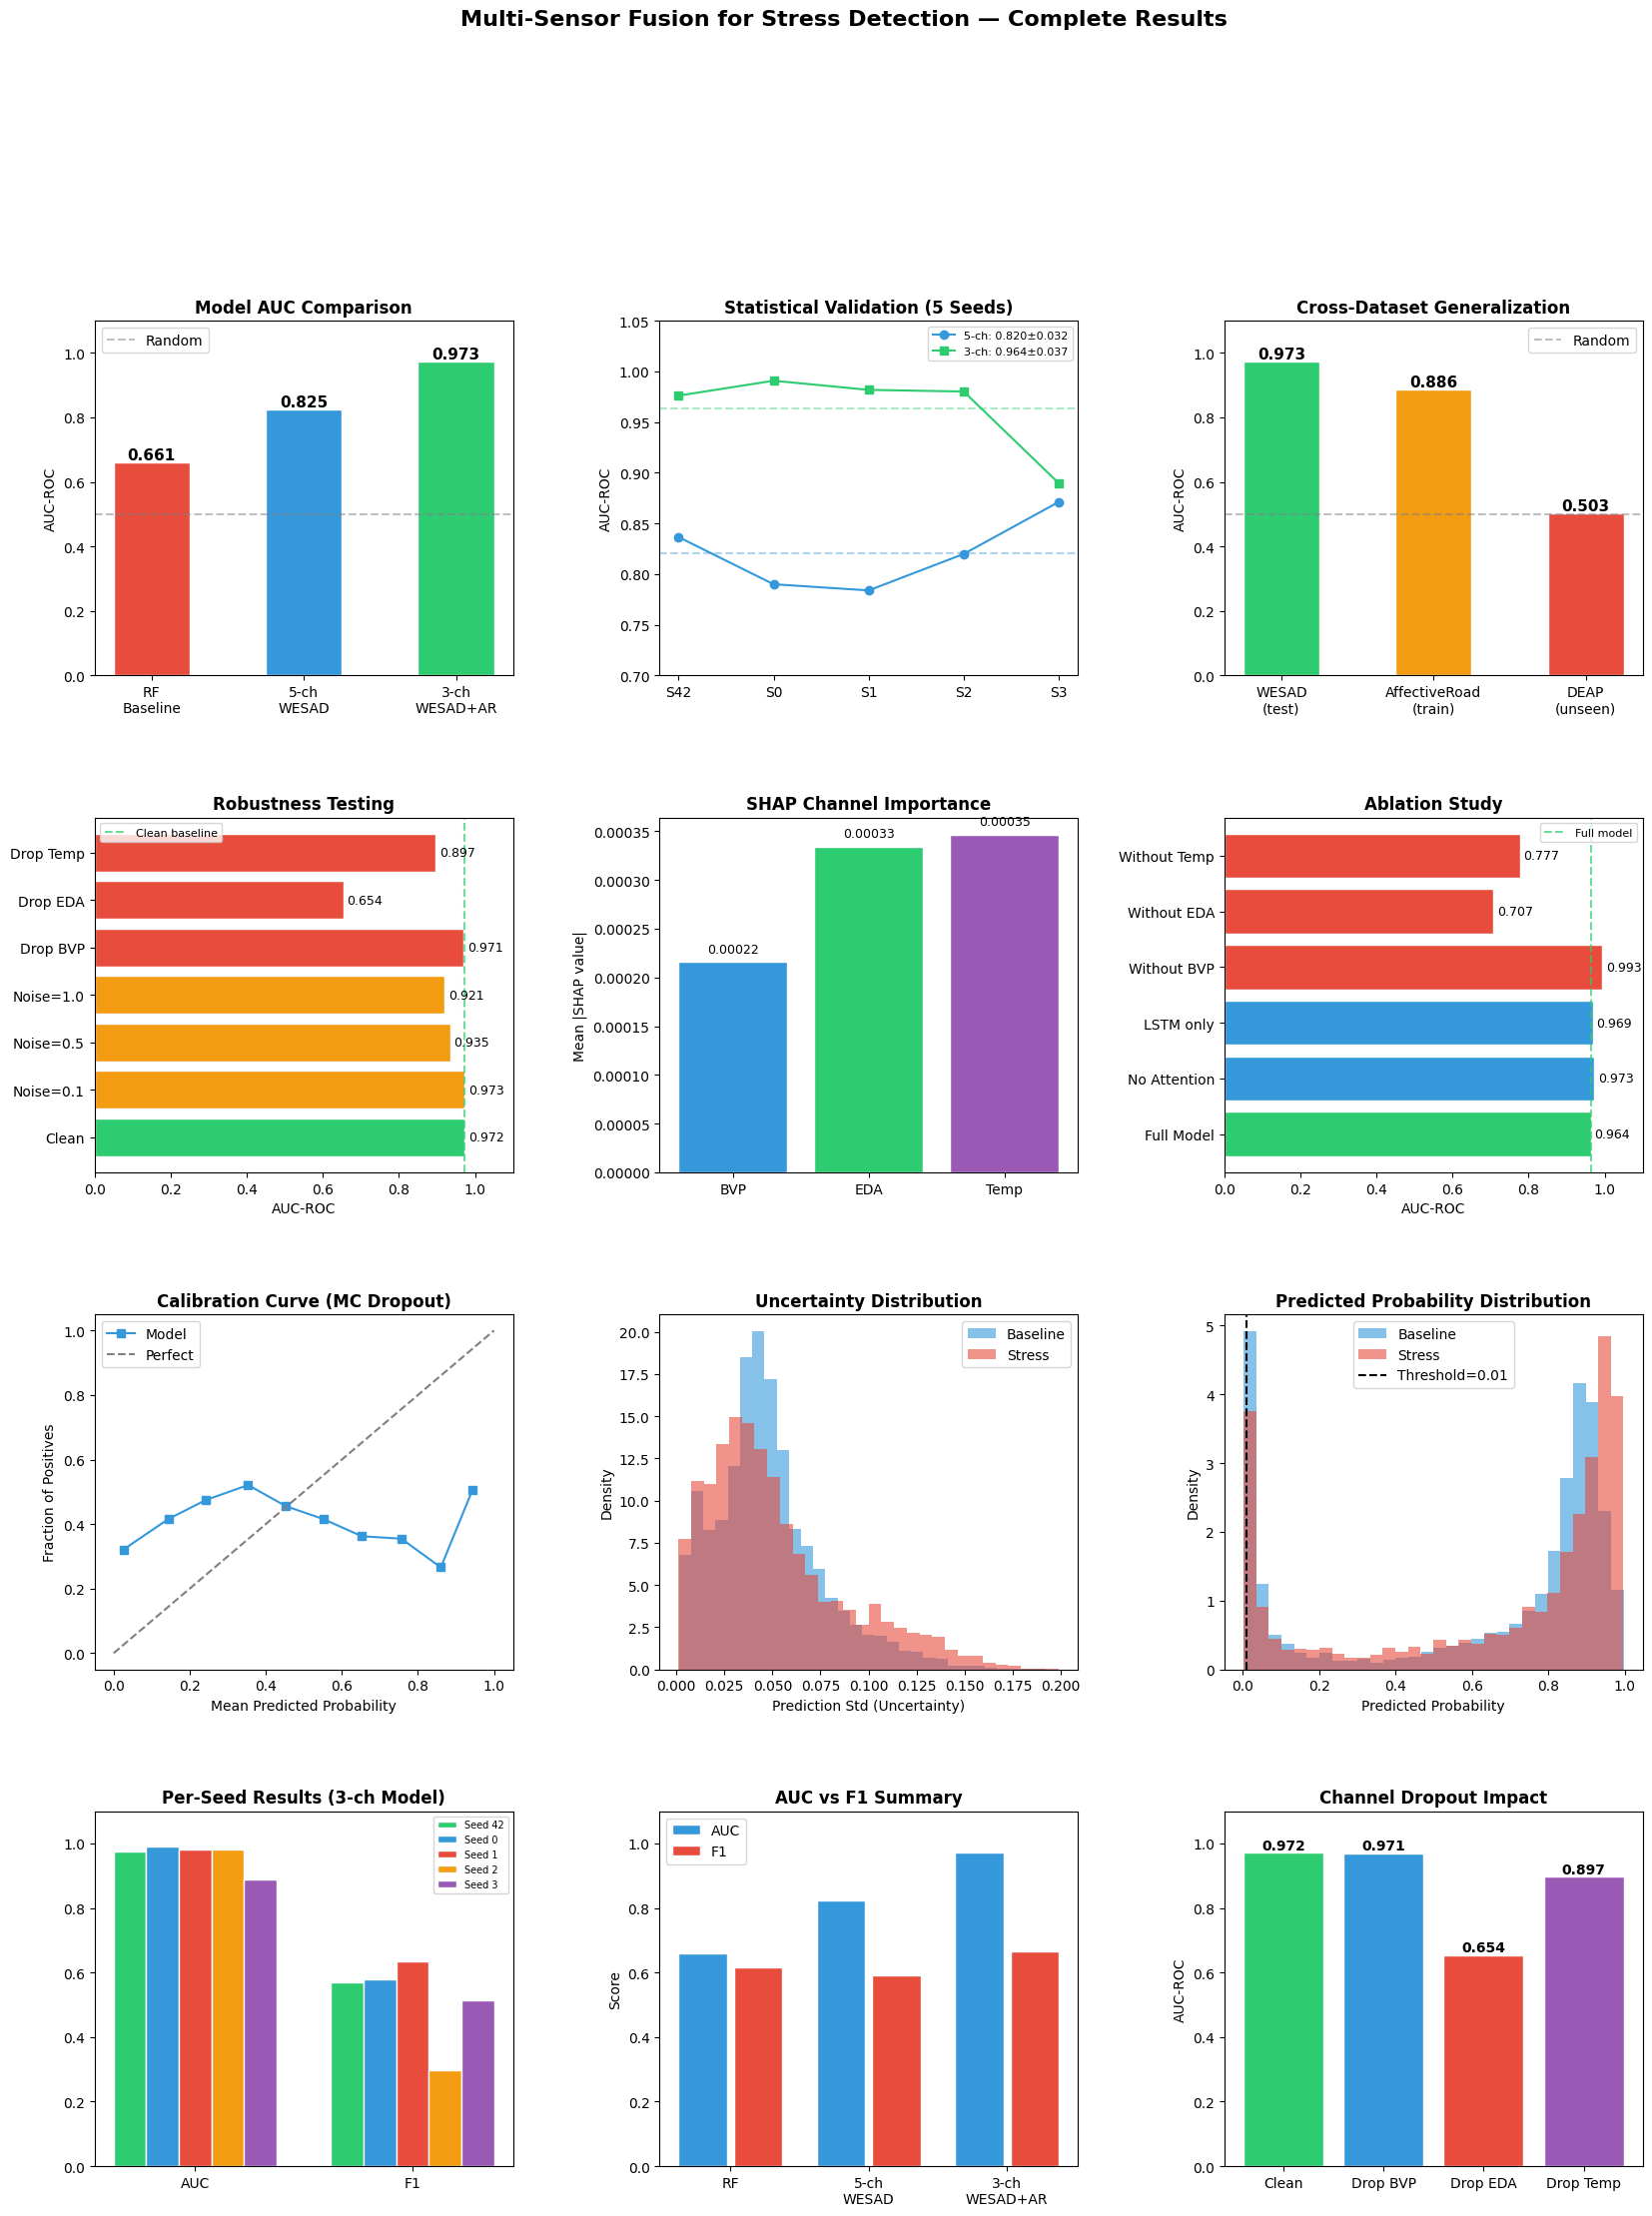

Saved: complete_results.png


In [21]:
from sklearn.calibration import calibration_curve

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Model Comparison ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models  = ['RF\nBaseline', '5-ch\nWESAD', '3-ch\nWESAD+AR']
aucs_c  = [0.6606, 0.8245, 0.9725]
colors  = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax1.bar(models, aucs_c, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, aucs_c):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.set_title('Model AUC Comparison', fontweight='bold')
ax1.set_ylabel('AUC-ROC')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax1.legend()

# ── 2. Statistical Validation (5 seeds) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
seeds_x   = [42, 0, 1, 2, 3]
aucs_5ch  = [r['auc'] for r in all_results]
aucs_3ch  = [r['auc'] for r in all_results_3ch]
ax2.plot(range(5), aucs_5ch, 'o-', color='#3498db', label=f'5-ch: {np.mean(aucs_5ch):.3f}±{np.std(aucs_5ch):.3f}')
ax2.plot(range(5), aucs_3ch, 's-', color='#2ecc71', label=f'3-ch: {np.mean(aucs_3ch):.3f}±{np.std(aucs_3ch):.3f}')
ax2.axhline(np.mean(aucs_5ch), color='#3498db', linestyle='--', alpha=0.4)
ax2.axhline(np.mean(aucs_3ch), color='#2ecc71', linestyle='--', alpha=0.4)
ax2.set_xticks(range(5))
ax2.set_xticklabels([f'S{s}' for s in seeds_x])
ax2.set_ylim(0.7, 1.05)
ax2.set_title('Statistical Validation (5 Seeds)', fontweight='bold')
ax2.set_ylabel('AUC-ROC')
ax2.legend(fontsize=8)

# ── 3. Cross-Dataset Generalization ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
datasets = ['WESAD\n(test)', 'AffectiveRoad\n(train)', 'DEAP\n(unseen)']
d_aucs   = [0.9725, 0.8856, 0.5029]
d_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars3 = ax3.bar(datasets, d_aucs, color=d_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars3, d_aucs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax3.set_ylim(0, 1.1)
ax3.set_title('Cross-Dataset Generalization', fontweight='bold')
ax3.set_ylabel('AUC-ROC')
ax3.legend()

# ── 4. Robustness Testing ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
rob_labels = list(rob_results.keys())
rob_aucs   = [v[0] for v in rob_results.values()]
rob_cols   = ['#2ecc71'] + ['#f39c12']*3 + ['#e74c3c']*3
bars4 = ax4.barh(rob_labels, rob_aucs, color=rob_cols, edgecolor='white')
ax4.axvline(0.9725, color='#2ecc71', linestyle='--', alpha=0.7, label='Clean baseline')
ax4.set_xlim(0, 1.1)
ax4.set_title('Robustness Testing', fontweight='bold')
ax4.set_xlabel('AUC-ROC')
ax4.legend(fontsize=8)
for bar, val in zip(bars4, rob_aucs):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# ── 5. SHAP Channel Importance ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
shap_colors = ['#3498db', '#2ecc71', '#9b59b6']
bars5 = ax5.bar(channels_3, shap_arr_3, color=shap_colors, edgecolor='white')
for bar, val in zip(bars5, shap_arr_3):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
             f'{val:.5f}', ha='center', fontsize=9)
ax5.set_title('SHAP Channel Importance', fontweight='bold')
ax5.set_ylabel('Mean |SHAP value|')

# ── 6. Ablation Study ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
abl_names = list(abl_results.keys())
abl_aucs  = [v[0] for v in abl_results.values()]
abl_cols  = ['#2ecc71'] + ['#3498db']*2 + ['#e74c3c']*3
bars6 = ax6.barh(abl_names, abl_aucs, color=abl_cols, edgecolor='white')
ax6.axvline(abl_results['Full Model'][0], color='#2ecc71',
            linestyle='--', alpha=0.7, label='Full model')
ax6.set_xlim(0, 1.1)
ax6.set_title('Ablation Study', fontweight='bold')
ax6.set_xlabel('AUC-ROC')
ax6.legend(fontsize=8)
for bar, val in zip(bars6, abl_aucs):
    ax6.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# ── 7. Calibration Curve ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
frac, mean_p = calibration_curve(y_te, mean_probs_mc, n_bins=10)
ax7.plot(mean_p, frac, 's-', color='#3498db', label='Model')
ax7.plot([0,1], [0,1], '--', color='gray', label='Perfect')
ax7.set_title('Calibration Curve (MC Dropout)', fontweight='bold')
ax7.set_xlabel('Mean Predicted Probability')
ax7.set_ylabel('Fraction of Positives')
ax7.legend()

# ── 8. Uncertainty Distribution ───────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
stress_unc   = std_probs_mc[y_te == 1]
baseline_unc = std_probs_mc[y_te == 0]
ax8.hist(baseline_unc, bins=30, alpha=0.6, color='#3498db', label='Baseline', density=True)
ax8.hist(stress_unc,   bins=30, alpha=0.6, color='#e74c3c', label='Stress',   density=True)
ax8.set_title('Uncertainty Distribution', fontweight='bold')
ax8.set_xlabel('Prediction Std (Uncertainty)')
ax8.set_ylabel('Density')
ax8.legend()

# ── 9. Probability Distribution ───────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
stress_p   = mean_probs_mc[y_te == 1]
baseline_p = mean_probs_mc[y_te == 0]
ax9.hist(baseline_p, bins=30, alpha=0.6, color='#3498db', label='Baseline', density=True)
ax9.hist(stress_p,   bins=30, alpha=0.6, color='#e74c3c', label='Stress',   density=True)
ax9.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
ax9.set_title('Predicted Probability Distribution', fontweight='bold')
ax9.set_xlabel('Predicted Probability')
ax9.set_ylabel('Density')
ax9.legend()

# ── 10. Training Progress (seeds) ─────────────────────────────────
ax10 = fig.add_subplot(gs[3, 0])
seed_labels = [f'Seed {s}' for s in [42,0,1,2,3]]
x = np.arange(2)
w = 0.15
seed_colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']
for i, (label, res) in enumerate(zip(seed_labels, all_results_3ch)):
    ax10.bar(x + i*w, [res['auc'], res['f1']], w, label=label,
             color=seed_colors[i], edgecolor='white')
ax10.set_xticks(x + w*2)
ax10.set_xticklabels(['AUC', 'F1'])
ax10.set_ylim(0, 1.1)
ax10.set_title('Per-Seed Results (3-ch Model)', fontweight='bold')
ax10.legend(fontsize=7)

# ── 11. Dataset Comparison Summary ────────────────────────────────
ax11 = fig.add_subplot(gs[3, 1])
summary_models = ['RF', '5-ch\nWESAD', '3-ch\nWESAD+AR']
summary_aucs   = [0.6606, 0.8245, 0.9725]
summary_f1s    = [0.6160, 0.5915, 0.6649]
x2 = np.arange(len(summary_models))
ax11.bar(x2 - 0.2, summary_aucs, 0.35, label='AUC', color='#3498db', edgecolor='white')
ax11.bar(x2 + 0.2, summary_f1s,  0.35, label='F1',  color='#e74c3c', edgecolor='white')
ax11.set_xticks(x2)
ax11.set_xticklabels(summary_models)
ax11.set_ylim(0, 1.1)
ax11.set_title('AUC vs F1 Summary', fontweight='bold')
ax11.set_ylabel('Score')
ax11.legend()

# ── 12. Channel Dropout Impact ────────────────────────────────────
ax12 = fig.add_subplot(gs[3, 2])
drop_names = ['Clean', 'Drop BVP', 'Drop EDA', 'Drop Temp']
drop_aucs  = [rob_results['Clean'][0],
              rob_results['Drop BVP'][0],
              rob_results['Drop EDA'][0],
              rob_results['Drop Temp'][0]]
drop_cols  = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
bars12 = ax12.bar(drop_names, drop_aucs, color=drop_cols, edgecolor='white')
for bar, val in zip(bars12, drop_aucs):
    ax12.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax12.set_ylim(0, 1.1)
ax12.set_title('Channel Dropout Impact', fontweight='bold')
ax12.set_ylabel('AUC-ROC')

plt.suptitle('Multi-Sensor Fusion for Stress Detection — Complete Results',
             fontsize=16, fontweight='bold', y=1.01)

plt.savefig('/kaggle/working/complete_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: complete_results.png")